This cell helps determine an appropriate epsilon for our DBSCAN (Density-based spatial clustering of applications with noise). Epsilon is the maximum radius within which seismic events must occur to be considered a "neighbor". For this study we use min_pts = 5, meaning a location is treated as dense only if it has at least five earthquakes within that radius or epsilon. The K‑distance graph shows where the distance to the 5th‑nearest neighbor increases, marking the transition from dense to sparse seismic events. The graph indicates this transition occurs around 40–50 km, making that an appropriate epsilon for our DBScan.

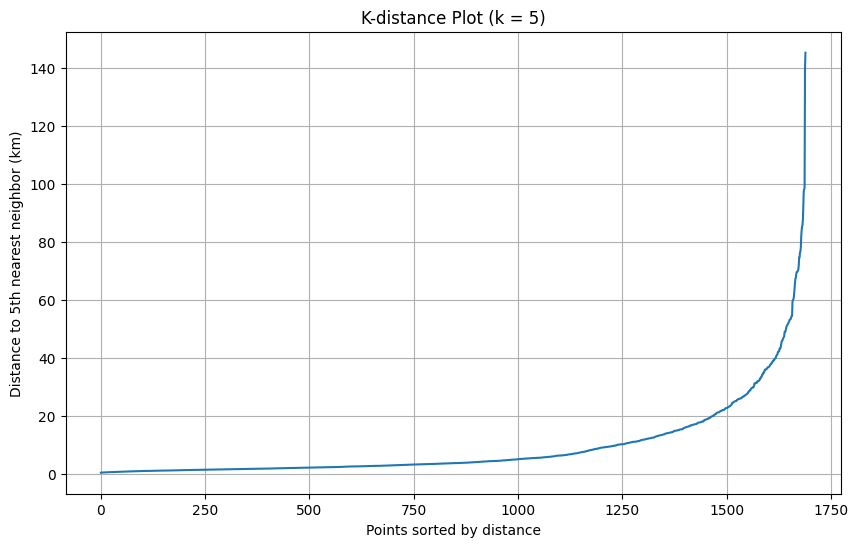

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1990-01-01&endtime=2026-06-31&minlatitude=32.5&minlongitude=-124.5&maxlatitude=42.0&maxlongitude=-114.1&minmagnitude=4.0"
df = pd.read_csv(url)

coords_rad = np.radians(df[['latitude', 'longitude']].values)

# min_pts = (a number of events within a radius to be considered a "neighbor")
min_pts = 5

nbrs = NearestNeighbors(n_neighbors=min_pts, metric='haversine').fit(coords_rad)
distances, indices = nbrs.kneighbors(coords_rad)
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

# radians → kilometers ( since we use the haversine metric for our neighbor the distance is in radians, we will convert it to km for this graph)
earth_radius_km = 6371.0088
k_distances_km = k_distances_sorted * earth_radius_km

# graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_km)
plt.title("K-distance Plot (k = 5)")
plt.xlabel("# of seimic events")
plt.ylabel("Distance to 5th nearest neighbor (km)")
plt.grid(True)
plt.show()
